In [40]:
import os, hashlib
from collections import Counter
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import os, yaml

In [41]:
def read_data_yaml(root):
    """Reads a Roboflow-style data.yaml and returns the class name list."""
    yaml_path = os.path.join(root, "data.yaml")
    if not os.path.isfile(yaml_path):
        print(f"[!] No data.yaml found in {root}")
        return None
    with open(yaml_path) as f:
        data = yaml.safe_load(f)
    return data.get("names")

def detect_splits(root):
    """Finds split folders (train/valid/test, or train/val/test, etc.) that contain images+labels."""
    found = {}
    for name in os.listdir(root):
        split_dir = os.path.join(root, name)
        if not os.path.isdir(split_dir):
            continue
        img_dir = os.path.join(split_dir, "images")
        lbl_dir = os.path.join(split_dir, "labels")
        if os.path.isdir(img_dir) and os.path.isdir(lbl_dir):
            found[name] = {"images": img_dir, "labels": lbl_dir}
    return found

ROOT = "data/raw/MosquitoFusion Dataset"      
splits = detect_splits(ROOT)
CLASS_NAMES = read_data_yaml(ROOT) 
print("Splits found:", list(splits.keys()))
print("Classes:", CLASS_NAMES)

Splits found: ['test', 'train', 'valid']
Classes: ['Breeding Place', 'Mosquito', 'Mosquito Swarm']


## 1. Check for corrupt images

In [42]:
def find_corrupt_images(img_dir):
    bad = []
    for f in os.listdir(img_dir):
        path = os.path.join(img_dir, f)
        try:
            im = Image.open(path)
            im.verify()
        except Exception:
            bad.append(path)
    return bad

for split, dirs in splits.items():
    bad = find_corrupt_images(dirs["images"])
    print(split, "-> corrupt images:", len(bad))

test -> corrupt images: 0
train -> corrupt images: 0
valid -> corrupt images: 0


## 2. Find exact duplicate images (MD5 hash)

In [43]:
def find_duplicates(img_dir):
    seen, dupes = {}, []
    for f in os.listdir(img_dir):
        path = os.path.join(img_dir, f)
        h = hashlib.md5(open(path, "rb").read()).hexdigest()
        if h in seen:
            dupes.append((path, seen[h]))
        else:
            seen[h] = path
    return dupes

for split, dirs in splits.items():
    dupes = find_duplicates(dirs["images"])
    print(split, "-> exact duplicates:", len(dupes))

test -> exact duplicates: 0
train -> exact duplicates: 1
valid -> exact duplicates: 0


## 3. Check every image has a matching label file (and vice versa)

In [44]:
def check_pairs(dirs):
    imgs = set(f.rsplit(".",1)[0] for f in os.listdir(dirs["images"]))
    lbls = set(f.rsplit(".",1)[0] for f in os.listdir(dirs["labels"]))
    return len(imgs - lbls), len(lbls - imgs)

for split, dirs in splits.items():
    no_lbl, no_img = check_pairs(dirs)
    print(split, "-> images without labels:", no_lbl, "| labels without images:", no_img)

test -> images without labels: 0 | labels without images: 0
train -> images without labels: 0 | labels without images: 0
valid -> images without labels: 0 | labels without images: 0


## 4. EDA — count objects per class

In [45]:
def count_classes(dirs):
    counts = Counter()
    for f in os.listdir(dirs["labels"]):
        with open(os.path.join(dirs["labels"], f)) as fh:
            for line in fh:
                if line.strip():
                    cid = int(line.split()[0])
                    name = CLASS_NAMES[cid] if CLASS_NAMES else str(cid)
                    counts[name] += 1
    return counts

all_counts = {split: count_classes(dirs) for split, dirs in splits.items()}
df_counts = pd.DataFrame(all_counts).fillna(0).astype(int)
df_counts

,test,train,valid
Breeding Place,81,2168,223
Mosquito,36,416,36
Mosquito Swarm,1,57,6


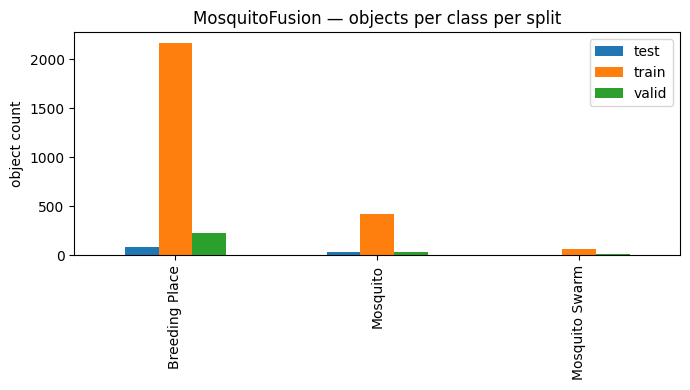

In [46]:
if not df_counts.empty:
    df_counts.plot(kind="bar", figsize=(7,4), title="MosquitoFusion — objects per class per split")
    plt.ylabel("object count")
    plt.tight_layout()
    plt.savefig("data/charts/mosquitofusion_class_distribution.png", dpi=150)
    plt.show()

## 5. Visualise a real label — worked example

In [47]:
#pip install opencv-python

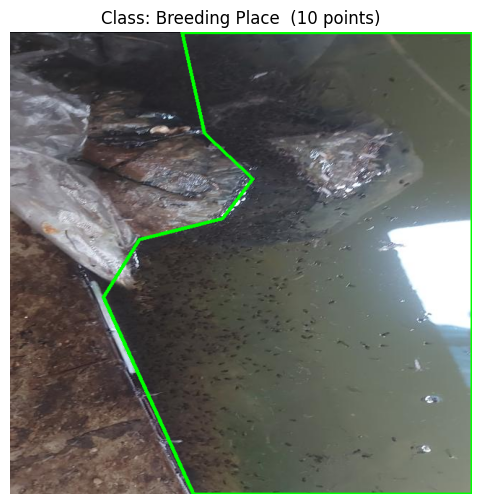

In [48]:
import cv2
import numpy as np

sample_img, sample_lbl = None, None
if os.path.isfile("1_png_rf_5a2c887f09f222c521765b4be6f51e37.jpg"):
    sample_img = "1_png_rf_5a2c887f09f222c521765b4be6f51e37.jpg"
    sample_lbl = "1_png_rf_5a2c887f09f222c521765b4be6f51e37.txt"
elif "train" in splits:
    lbl_files = os.listdir(splits["train"]["labels"])
    if lbl_files:
        stem = lbl_files[0].rsplit(".", 1)[0]
        sample_lbl = os.path.join(splits["train"]["labels"], lbl_files[0])
        for ext in [".jpg", ".jpeg", ".png"]:
            candidate = os.path.join(splits["train"]["images"], stem + ext)
            if os.path.isfile(candidate):
                sample_img = candidate
                break

if sample_img and sample_lbl:
    img = cv2.imread(sample_img)
    h, w = img.shape[:2]
    with open(sample_lbl) as f:
        parts = f.readline().split()
    cls_id = int(parts[0])
    coords = [float(x) for x in parts[1:]]
    points = [[int(coords[i]*w), int(coords[i+1]*h)] for i in range(0, len(coords), 2)]
    points = np.array(points, dtype=np.int32)
    vis = img.copy()
    cv2.polylines(vis, [points], isClosed=True, color=(0,255,0), thickness=3)
    label_name = CLASS_NAMES[cls_id] if CLASS_NAMES else str(cls_id)
    vis_rgb = cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6,6)); plt.imshow(vis_rgb)
    plt.title(f"Class: {label_name}  ({len(points)} points)"); plt.axis("off")
    plt.savefig("data/charts/label_check_sample.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No sample image/label pair found to visualise - adjust paths above.")

## 6. Blur & brightness check (flag risky images)

In [49]:
def blur_score(path):
    g = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return cv2.Laplacian(g, cv2.CV_64F).var()

def brightness_score(path):
    g = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    return g.mean()

if sample_img:
    print("Sample blur score:", round(blur_score(sample_img), 1), " (below ~100 = risky/too blurry)")
    print("Sample brightness:", round(brightness_score(sample_img), 1), " (below 40 or above 220 = risky)")

Sample blur score: 445.0  (below ~100 = risky/too blurry)
Sample brightness: 94.2  (below 40 or above 220 = risky)


## 7. Resize + normalize (preprocessing for MobileNetV3 input)

In [50]:
TARGET_SIZE = (224, 224)   # MobileNetV3 default input size

def resize_and_normalize(path, size=TARGET_SIZE):
    im = Image.open(path).convert("RGB").resize(size, Image.BILINEAR)
    return np.asarray(im).astype("float32") / 255.0

if sample_img:
    arr = resize_and_normalize(sample_img)
    print("Preprocessed array shape:", arr.shape, "| value range:", arr.min(), "-", arr.max())

Preprocessed array shape: (224, 224, 3) | value range: 0.1254902 - 1.0


## 8. Augmentation — how many training images will you end up with?

In [51]:
# Find the breeding-site class id from the real data.yaml (no more guessing the index)
BREEDING_SITE_NAME_CANDIDATES = [n for n in (CLASS_NAMES or []) if "breed" in n.lower()]
print("Detected breeding-site-like class name(s):", BREEDING_SITE_NAME_CANDIDATES)

TARGET_IMAGES = 4000
if "train" in all_counts and BREEDING_SITE_NAME_CANDIDATES:
    original_count = all_counts["train"].get(BREEDING_SITE_NAME_CANDIDATES[0], 0)
    if original_count:
        multiplier_needed = TARGET_IMAGES / original_count
        print(f"MosquitoFusion-only breeding-site train images: {original_count}")
        print(f"Preview multiplier if using MosquitoFusion alone: {multiplier_needed:.2f}x")
        print("(Notebook 04 recalculates this after adding VisText-Mosquito - expect a lower, better multiplier.)")
    else:
        print("No breeding-site labels counted yet - check Section 4 output above.")
else:
    print("Run Section 4 first, and confirm the real breeding-site class name from data.yaml.")

Detected breeding-site-like class name(s): ['Breeding Place']
MosquitoFusion-only breeding-site train images: 2168
Preview multiplier if using MosquitoFusion alone: 1.85x
(Notebook 04 recalculates this after adding VisText-Mosquito - expect a lower, better multiplier.)


In [52]:
import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.6, border_mode=cv2.BORDER_REFLECT101),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.6),
    A.RandomCrop(width=576, height=576, p=0.3),
    A.GaussNoise(p=0.2),
    A.ToGray(p=0.15),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def augment_one_image(img_path, label_path, n_copies, out_img_dir, out_lbl_dir, stem):
    """Generates n_copies augmented versions of one image+label pair (YOLO bbox format)."""
    image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    bboxes, class_labels = [], []
    for line in open(label_path):
        parts = line.split()
        if len(parts) == 5:
            cid, x, y, w, h = parts
            bboxes.append([float(x), float(y), float(w), float(h)])
            class_labels.append(int(cid))
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)
    for i in range(n_copies):
        out = transform(image=image, bboxes=bboxes, class_labels=class_labels)
        aug_img = cv2.cvtColor(out['image'], cv2.COLOR_RGB2BGR)
        out_stem = f"{stem}_aug{i}"
        cv2.imwrite(os.path.join(out_img_dir, out_stem + ".jpg"), aug_img)
        with open(os.path.join(out_lbl_dir, out_stem + ".txt"), "w") as f:
            for cid, box in zip(out['class_labels'], out['bboxes']):
                f.write(f"{cid} {' '.join(f'{v:.6f}' for v in box)}\n")

print("augment_one_image() ready - reused by Notebook 04 on the merged train set.")

augment_one_image() ready - reused by Notebook 04 on the merged train set.
